# XEMM Basic Demo

Load tabulated material data, interpolate refractive index values, then evaluate the same material model with `jax.jit` and differentiate it with `jax.grad`.

In [1]:
import jax
import jax.numpy as jp
import matplotlib.pyplot as plt

from xemm import MaterialData

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


  importing... Silver (Ag), Johnson & Christy


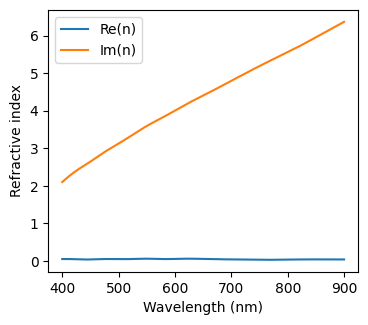

In [2]:
material = MaterialData.from_file('Ag/Johnson', unit='nm', parm='n')
wavelengths = jp.linspace(400.0, 900.0, 201)
refractive_index = material.interp(wavelengths, unit='nm', parm='n', kind='cubic')

plt.figure(figsize=(4.0,3.4))
plt.plot(wavelengths, jp.real(refractive_index), label='Re(n)')
plt.plot(wavelengths, jp.imag(refractive_index), label='Im(n)')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Refractive index')
plt.legend()
plt.show()

In [3]:
@jax.jit
def permittivity_at(wavelength_nm):
  return material.interp(
    wavelength_nm,
    unit='nm',
    parm='e',
    kind='cubic',
    extrap='constant',
  )

wavelength_nm = 500.0
permittivity = permittivity_at(wavelength_nm)
permittivity_gradient = jax.grad(
  lambda value: jp.real(permittivity_at(value))
)(wavelength_nm)

print(f'epsilon({wavelength_nm:.0f} nm) = {permittivity}')
print(f'd Re(epsilon) / d wavelength = {permittivity_gradient}')

epsilon(500 nm) = (-9.792701721191406+0.3091886341571808j)
d Re(epsilon) / d wavelength = -0.056413255631923676


  importing... Germanium (Ge), Aspnes & Studna


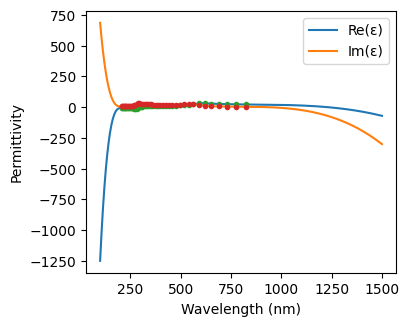

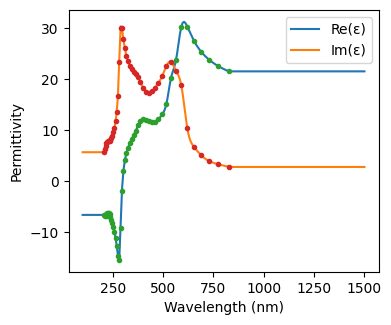

In [4]:
material = MaterialData.from_file('Ge/Aspnes', unit='nm', parm='e')
wavelengths = jp.linspace(100.0, 1500.0, 201)
eps = material.interp(wavelengths, unit='nm', parm='e', kind='cubic', extrap=True)

plt.figure(figsize=(4.0,3.4))
plt.plot(wavelengths, jp.real(eps), label='Re(ε)')
plt.plot(wavelengths, jp.imag(eps), label='Im(ε)')
plt.plot(material.f, material.re, '.')
plt.plot(material.f, material.im, '.')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Permittivity')
plt.legend()
plt.show()

eps = material.interp(wavelengths, unit='nm', parm='e', kind='cubic', extrap=False)

plt.figure(figsize=(4.0,3.4))
plt.plot(wavelengths, jp.real(eps), label='Re(ε)')
plt.plot(wavelengths, jp.imag(eps), label='Im(ε)')
plt.plot(material.f, material.re, '.')
plt.plot(material.f, material.im, '.')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Permittivity')
plt.legend()
plt.show()